# Recipe Matching Model

> **Objective:** Build an ingredient-to-recipe index, implement set-similarity matching (Jaccard & Cosine on binary ingredient vectors) to rank recipes, and evaluate with hit rate, mean reciprocal rank (MRR), and ingredient coverage.

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

# --- PATHS (edit here if your folder names differ) ---
HOME_DIR = '/content/drive/Shareddrives/Computer Vision Final Project'
DATA_DIR = os.path.join(HOME_DIR, 'Data', 'recipe_dataset', 'data')
MODEL_DIR = os.path.join(HOME_DIR, 'Modeling')
OUT_DIR = os.path.join(MODEL_DIR, 'output_plots')

os.makedirs(OUT_DIR, exist_ok=True)
os.chdir(MODEL_DIR)

# Verify data
parquet_path = os.path.join(DATA_DIR, 'recipes.parquet')
csv_path = os.path.join(DATA_DIR, 'recipes.csv')
if os.path.exists(parquet_path):
    print(f'Data found: {parquet_path}')
elif os.path.exists(csv_path):
    print(f'Data found (CSV): {csv_path}')
else:
    print(f'WARNING: Data NOT found in {DATA_DIR}')
    print('Contents:', os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR) else 'DIR MISSING')


Data found: /content/drive/Shareddrives/Computer Vision Final Project/Data/recipe_dataset/data/recipes.parquet


In [3]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast, re, warnings, time
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 180,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial'],
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

print('Libraries loaded.')


Libraries loaded.


In [4]:
if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
else:
    df = pd.read_csv(csv_path)

print(f'Loaded {len(df):,} recipes  |  Columns: {list(df.columns)}')
df.head(3)


Loaded 13,509 recipes  |  Columns: ['dish_id', 'dish_name', 'recipe', 'photo_path', 'source']


,dish_id,dish_name,recipe,photo_path,source
0,KG-000001,Miso-Butter Roast Chicken With Acorn Squash Pa...,"Ingredients:\n['1 (3½–4-lb.) whole chicken', '...",photos/KG-000001.jpg,kaggle_epicurious
1,KG-000002,Crispy Salt and Pepper Potatoes,"Ingredients:\n['2 large egg whites', '1 pound ...",photos/KG-000002.jpg,kaggle_epicurious
2,KG-000003,Thanksgiving Mac and Cheese,"Ingredients:\n['1 cup evaporated milk', '1 cup...",photos/KG-000003.jpg,kaggle_epicurious


---
## 1 - Ingredient Parsing & Normalisation

We reuse the same parsing pipeline from the EDA notebook: extract ingredient lists from each recipe's text, strip quantities/units/prep-verbs, and store a clean set of ingredient names per recipe.


In [5]:
_UNITS = {
    'cup','cups','tbsp','tsp','tablespoon','tablespoons','teaspoon','teaspoons',
    'oz','ounce','ounces','lb','lbs','pound','pounds','quart','quarts','gallon',
    'gallons','pint','pints','ml','g','kg','liter','liters','inch','inches',
    'clove','cloves','can','cans','stick','sticks','package','packages','pinch',
    'piece','pieces','slice','slices','sprig','sprigs','bunch','bunches','head','heads',
    'small','medium','large','whole','half'
}
_PREP_VERBS = {
    'chopped','diced','minced','sliced','grated','crushed','peeled','melted',
    'softened','divided','optional','fresh','freshly','finely','coarsely',
    'roughly','thinly','plus','about','to','taste','for','garnish','more',
    'room','temperature','extra','additional'
}
_STOPWORDS = {'', 'salt', 'pepper', 'water', 'kosher salt', 'salt and', 'and pepper',
              'freshly ground pepper', 'freshly ground black pepper',
              'kosher salt freshly ground pepper', 'black pepper'}
_NUM_RE = re.compile(r'^[\d\u00bc\u00bd\u00be\u2153\u2154\u215b\u215c\u215d\u215e/.\-\u2013\u2014]+$')

def _clean_ingredient(raw: str) -> str:
    raw = re.sub(r'\(.*?\)', '', raw)
    raw = re.sub(r'[,;].*', '', raw)
    tokens = raw.lower().split()
    tokens = [t.strip('\'\"') for t in tokens]
    tokens = [t for t in tokens if not _NUM_RE.match(t)]
    tokens = [t for t in tokens if t not in _UNITS and t not in _PREP_VERBS]
    name = ' '.join(tokens).strip(' -\u2013\u2014\u2022')
    return name if name else raw.lower().strip()

def parse_ingredients(recipe_text: str) -> list:
    if pd.isna(recipe_text):
        return []
    ingr_block = recipe_text.split('Instructions:')[0].replace('Ingredients:', '').strip() if 'Instructions:' in recipe_text else recipe_text.replace('Ingredients:', '').strip()
    raw_items = []
    if ingr_block.startswith('['):
        try:
            raw_items = ast.literal_eval(ingr_block)
        except Exception:
            raw_items = [s.strip(" '\"") for s in ingr_block.strip('[]').split("',")]
    else:
        raw_items = [line.lstrip('- ').strip() for line in ingr_block.splitlines() if line.strip().startswith('-')]
    cleaned = [_clean_ingredient(i) for i in raw_items if i.strip()]
    return [c for c in cleaned if c not in _STOPWORDS]

df['ingredients'] = df['recipe'].apply(parse_ingredients)
df['ingredient_set'] = df['ingredients'].apply(set)
df['n_ingredients'] = df['ingredients'].apply(len)

# Drop recipes with 0 ingredients
before = len(df)
df = df[df['n_ingredients'] > 0].reset_index(drop=True)
print(f'Parsed {len(df):,} recipes (dropped {before - len(df)} with 0 ingredients).')
print(f'Avg ingredients/recipe: {df["n_ingredients"].mean():.1f}')


Parsed 13,502 recipes (dropped 7 with 0 ingredients).
Avg ingredients/recipe: 10.0


---
## 2 - Ingredient-to-Recipe Index

We build two structures:
1. **Forward index** (`recipe_id -> set of ingredients`)
2. **Inverted index** (`ingredient -> set of recipe_ids`)

Plus a binary ingredient matrix for vectorised similarity.


In [6]:
# --- Forward index ---
recipe_index = {}
for idx, row in df.iterrows():
    recipe_index[idx] = {
        'dish_id': row['dish_id'],
        'dish_name': row['dish_name'],
        'ingredients': row['ingredient_set'],
        'n_ingredients': row['n_ingredients'],
    }

# --- Inverted index ---
inverted_index = {}
for idx, row in df.iterrows():
    for ingr in row['ingredient_set']:
        if ingr not in inverted_index:
            inverted_index[ingr] = set()
        inverted_index[ingr].add(idx)

print(f'Forward index : {len(recipe_index):,} recipes')
print(f'Inverted index: {len(inverted_index):,} unique ingredients')
print(f'\nTop 10 most common ingredients (by recipe count):')
top10 = sorted(inverted_index.items(), key=lambda x: len(x[1]), reverse=True)[:10]
for ingr, rids in top10:
    print(f'  {ingr:30s}  appears in {len(rids):>5,} recipes')


Forward index : 13,502 recipes
Inverted index: 25,337 unique ingredients

Top 10 most common ingredients (by recipe count):
  garlic                          appears in 3,749 recipes
  sugar                           appears in 2,823 recipes
  unsalted butter                 appears in 2,816 recipes
  olive oil                       appears in 2,580 recipes
  eggs                            appears in 1,805 recipes
  ground black pepper             appears in 1,760 recipes
  lemon juice                     appears in 1,729 recipes
  extra-virgin olive oil          appears in 1,701 recipes
  all-purpose flour               appears in 1,468 recipes
  vegetable oil                   appears in 1,244 recipes


In [7]:
# Build a binary ingredient matrix (recipes x ingredients)
# Filter to ingredients appearing in >= 3 recipes to keep matrix manageable
MIN_FREQ = 3
valid_ingr = sorted([ingr for ingr, rids in inverted_index.items() if len(rids) >= MIN_FREQ])
ingr_to_col = {ingr: i for i, ingr in enumerate(valid_ingr)}

n_recipes = len(df)
n_features = len(valid_ingr)

# Build sparse matrix
rows, cols, data = [], [], []
for idx, row in df.iterrows():
    for ingr in row['ingredient_set']:
        if ingr in ingr_to_col:
            rows.append(idx)
            cols.append(ingr_to_col[ingr])
            data.append(1)

ingredient_matrix = csr_matrix((data, (rows, cols)), shape=(n_recipes, n_features), dtype=np.float32)

print(f'Binary ingredient matrix: {ingredient_matrix.shape}')
print(f'  Recipes   : {n_recipes:,}')
print(f'  Features  : {n_features:,} ingredients (appearing in >= {MIN_FREQ} recipes)')
print(f'  Sparsity  : {1 - ingredient_matrix.nnz / (n_recipes * n_features):.4%}')
print(f'  Non-zeros : {ingredient_matrix.nnz:,}')


Binary ingredient matrix: (13502, 3821)
  Recipes   : 13,502
  Features  : 3,821 ingredients (appearing in >= 3 recipes)
  Sparsity  : 99.7933%
  Non-zeros : 106,654


---
## 3 - Set-Similarity Matching

Given a query set of ingredients (simulating what might be detected from an image), we rank all recipes by two similarity measures:

| Method | Formula |
|--------|--------|
| **Jaccard** | \|A \cap B\| / \|A \cup B\| |
| **Cosine** | (A \cdot B) / (\|\|A\|\| \cdot \|\|B\|\|) |

where A = query ingredient vector and B = recipe ingredient vector.


In [8]:
def jaccard_rank(query_set: set, top_k: int = 10) -> list:
    """
    Rank all recipes by Jaccard similarity to query_set.
    Returns list of (recipe_idx, score) tuples.
    """
    # Use inverted index for speed: only score recipes sharing >= 1 ingredient
    candidate_ids = set()
    for ingr in query_set:
        if ingr in inverted_index:
            candidate_ids |= inverted_index[ingr]

    scores = []
    for rid in candidate_ids:
        recipe_ingr = recipe_index[rid]['ingredients']
        intersection = len(query_set & recipe_ingr)
        union = len(query_set | recipe_ingr)
        scores.append((rid, intersection / union if union > 0 else 0.0))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]


def cosine_rank(query_set: set, top_k: int = 10) -> list:
    """
    Rank all recipes by cosine similarity on binary vectors.
    """
    # Build query vector
    query_vec = np.zeros((1, n_features), dtype=np.float32)
    for ingr in query_set:
        if ingr in ingr_to_col:
            query_vec[0, ingr_to_col[ingr]] = 1.0

    if query_vec.sum() == 0:
        return []

    sims = cosine_similarity(query_vec, ingredient_matrix).flatten()
    top_indices = np.argsort(sims)[::-1][:top_k]
    return [(int(i), float(sims[i])) for i in top_indices if sims[i] > 0]


print('Matching functions defined: jaccard_rank(), cosine_rank()')


Matching functions defined: jaccard_rank(), cosine_rank()


### Demo: Sample Queries

Let's test both methods on a few example ingredient sets.


In [9]:
demo_queries = [
    {'garlic', 'olive oil', 'lemon juice', 'chicken', 'thyme'},
    {'unsalted butter', 'sugar', 'eggs', 'all-purpose flour', 'vanilla extract'},
    {'soy sauce', 'ginger', 'rice vinegar', 'sesame oil', 'scallions'},
]

for i, query in enumerate(demo_queries):
    print(f'\n{"=" * 70}')
    print(f'Query {i+1}: {query}')
    print(f'{"=" * 70}')

    j_results = jaccard_rank(query, top_k=5)
    c_results = cosine_rank(query, top_k=5)

    print(f'\n  {"Jaccard Top-5":40s}  {"Cosine Top-5"}')
    print(f'  {"-" * 40}  {"-" * 40}')
    for rank in range(5):
        j_name = recipe_index[j_results[rank][0]]['dish_name'][:35] if rank < len(j_results) else ''
        j_score = f'{j_results[rank][1]:.3f}' if rank < len(j_results) else ''
        c_name = recipe_index[c_results[rank][0]]['dish_name'][:35] if rank < len(c_results) else ''
        c_score = f'{c_results[rank][1]:.3f}' if rank < len(c_results) else ''
        print(f'  {rank+1}. {j_name:33s} ({j_score})   {rank+1}. {c_name:33s} ({c_score})')



Query 1: {'chicken', 'lemon juice', 'garlic', 'olive oil', 'thyme'}

  Jaccard Top-5                             Cosine Top-5
  ----------------------------------------  ----------------------------------------
  1. Roasted Chicken with Garlic Confit (0.667)   1. Roasted Chicken with Garlic Confit (0.800)
  2. Grilled Leg of Lamb with Thyme and  (0.444)   2. One-Dish Baked Chicken with Tomatoe (0.676)
  3. Garlicky Blender Aioli            (0.429)   3. Salt-Crust Chicken                (0.671)
  4. Slow-Roasted Chicken With All the G (0.429)   4. Cast-Iron Roast Chicken           (0.632)
  5. Sunny Dressing                    (0.429)   5. Basic Lemon Vinaigrette           (0.632)

Query 2: {'eggs', 'vanilla extract', 'unsalted butter', 'all-purpose flour', 'sugar'}

  Jaccard Top-5                             Cosine Top-5
  ----------------------------------------  ----------------------------------------
  1. Basic Crepes                      (0.714)   1. Cocoa Brownies              

---
## 4 - Evaluation Framework

We simulate a realistic evaluation scenario:

1. **For each test recipe**, randomly sample a subset of its ingredients as the "detected" query (simulating partial ingredient detection, e.g. from a photo).
2. **Rank all recipes** using Jaccard and Cosine similarity.
3. **Measure** whether the original recipe appears in the top-K results.

### Metrics
| Metric | Definition |
|--------|------------|
| **Hit Rate @ K** | Fraction of queries where the true recipe is in the top-K |
| **Mean Reciprocal Rank (MRR)** | Average of 1/rank of the true recipe |
| **Ingredient Coverage** | Fraction of query ingredients matched by the top-1 recipe |


In [10]:
def evaluate(method_fn, test_indices, query_sets, true_recipe_ids, top_k=10):
    """
    Evaluate a ranking method.
    Returns dict with hit_rate@K, MRR, and ingredient coverage.
    """
    hits = 0
    reciprocal_ranks = []
    coverages = []

    for i, (q_set, true_id) in enumerate(zip(query_sets, true_recipe_ids)):
        results = method_fn(q_set, top_k=top_k)
        result_ids = [r[0] for r in results]

        # Hit rate
        if true_id in result_ids:
            hits += 1
            rank = result_ids.index(true_id) + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)

        # Coverage: what fraction of query ingredients does the top-1 result cover?
        if results:
            top1_ingr = recipe_index[results[0][0]]['ingredients']
            covered = len(q_set & top1_ingr)
            coverages.append(covered / len(q_set) if len(q_set) > 0 else 0)
        else:
            coverages.append(0.0)

    n = len(query_sets)
    return {
        'hit_rate': hits / n,
        'mrr': np.mean(reciprocal_ranks),
        'coverage': np.mean(coverages),
        'n_queries': n,
    }

print('evaluate() function defined.')


evaluate() function defined.


### Generate Test Set

We sample 1,000 recipes and for each one, randomly select 40-80% of its ingredients as the query. The true recipe is the one we sampled from.


In [11]:
np.random.seed(42)

N_TEST = 1000
test_indices = np.random.choice(len(df), size=N_TEST, replace=False)

query_sets = []
true_recipe_ids = []
query_fractions = []

for idx in test_indices:
    full_set = df.iloc[idx]['ingredient_set']
    if len(full_set) < 2:
        continue
    # Sample 40-80% of ingredients
    frac = np.random.uniform(0.4, 0.8)
    n_sample = max(1, int(len(full_set) * frac))
    sampled = set(np.random.choice(list(full_set), size=n_sample, replace=False))
    query_sets.append(sampled)
    true_recipe_ids.append(idx)
    query_fractions.append(n_sample / len(full_set))

print(f'Test set: {len(query_sets):,} queries')
print(f'Avg query fraction: {np.mean(query_fractions):.1%} of original ingredients')
print(f'Avg query size: {np.mean([len(q) for q in query_sets]):.1f} ingredients')


Test set: 997 queries
Avg query fraction: 53.2% of original ingredients
Avg query size: 5.3 ingredients


In [12]:
# Evaluate both methods at multiple K values
K_VALUES = [1, 3, 5, 10, 20, 50]

results_jaccard = {}
results_cosine = {}

print('Evaluating Jaccard...')
t0 = time.time()
for k in K_VALUES:
    results_jaccard[k] = evaluate(jaccard_rank, test_indices, query_sets, true_recipe_ids, top_k=k)
    print(f'  K={k:>2d}  |  Hit Rate: {results_jaccard[k]["hit_rate"]:.3f}  |  MRR: {results_jaccard[k]["mrr"]:.3f}  |  Coverage: {results_jaccard[k]["coverage"]:.3f}')
t_jaccard = time.time() - t0

print(f'\nEvaluating Cosine...')
t0 = time.time()
for k in K_VALUES:
    results_cosine[k] = evaluate(cosine_rank, test_indices, query_sets, true_recipe_ids, top_k=k)
    print(f'  K={k:>2d}  |  Hit Rate: {results_cosine[k]["hit_rate"]:.3f}  |  MRR: {results_cosine[k]["mrr"]:.3f}  |  Coverage: {results_cosine[k]["coverage"]:.3f}')
t_cosine = time.time() - t0

print(f'\nTiming: Jaccard {t_jaccard:.1f}s  |  Cosine {t_cosine:.1f}s')


Evaluating Jaccard...
  K= 1  |  Hit Rate: 0.912  |  MRR: 0.912  |  Coverage: 0.984
  K= 3  |  Hit Rate: 0.967  |  MRR: 0.937  |  Coverage: 0.984
  K= 5  |  Hit Rate: 0.978  |  MRR: 0.939  |  Coverage: 0.984
  K=10  |  Hit Rate: 0.987  |  MRR: 0.941  |  Coverage: 0.984
  K=20  |  Hit Rate: 0.994  |  MRR: 0.941  |  Coverage: 0.984
  K=50  |  Hit Rate: 0.999  |  MRR: 0.941  |  Coverage: 0.984

Evaluating Cosine...
  K= 1  |  Hit Rate: 0.743  |  MRR: 0.743  |  Coverage: 0.884
  K= 3  |  Hit Rate: 0.846  |  MRR: 0.790  |  Coverage: 0.884
  K= 5  |  Hit Rate: 0.884  |  MRR: 0.798  |  Coverage: 0.884
  K=10  |  Hit Rate: 0.922  |  MRR: 0.804  |  Coverage: 0.884
  K=20  |  Hit Rate: 0.952  |  MRR: 0.806  |  Coverage: 0.884
  K=50  |  Hit Rate: 0.966  |  MRR: 0.806  |  Coverage: 0.884

Timing: Jaccard 45.1s  |  Cosine 16.2s


---
## 5 - Results Visualisation


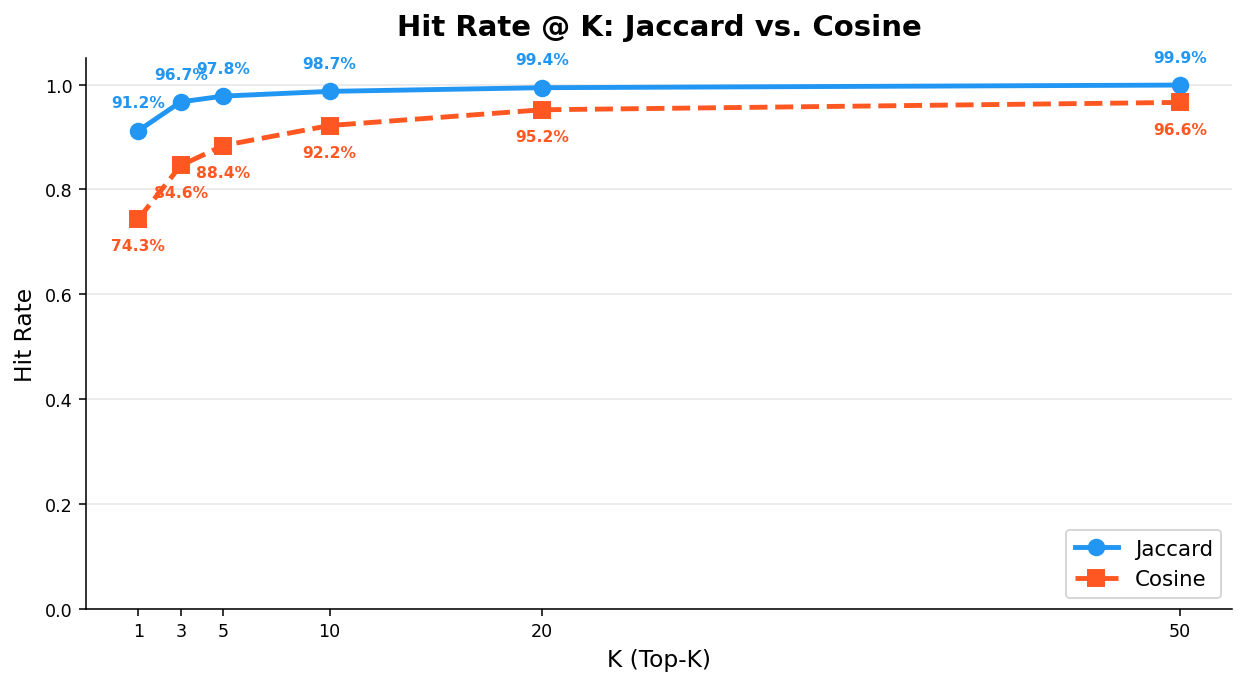

In [13]:
# --- Plot 1: Hit Rate @ K ---
fig, ax = plt.subplots(figsize=(9, 5))

hr_jaccard = [results_jaccard[k]['hit_rate'] for k in K_VALUES]
hr_cosine = [results_cosine[k]['hit_rate'] for k in K_VALUES]

ax.plot(K_VALUES, hr_jaccard, 'o-', color='#2196F3', linewidth=2.5, markersize=8, label='Jaccard')
ax.plot(K_VALUES, hr_cosine, 's--', color='#FF5722', linewidth=2.5, markersize=8, label='Cosine')

for k, hj, hc in zip(K_VALUES, hr_jaccard, hr_cosine):
    ax.annotate(f'{hj:.1%}', (k, hj), textcoords='offset points', xytext=(0, 12),
                fontsize=8, ha='center', color='#2196F3', weight='bold')
    ax.annotate(f'{hc:.1%}', (k, hc), textcoords='offset points', xytext=(0, -16),
                fontsize=8, ha='center', color='#FF5722', weight='bold')

ax.set_xlabel('K (Top-K)', fontsize=12)
ax.set_ylabel('Hit Rate', fontsize=12)
ax.set_title('Hit Rate @ K: Jaccard vs. Cosine', fontsize=15, weight='bold', pad=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.05)
ax.set_xticks(K_VALUES)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'hit_rate_at_k.png'), bbox_inches='tight')
plt.show()


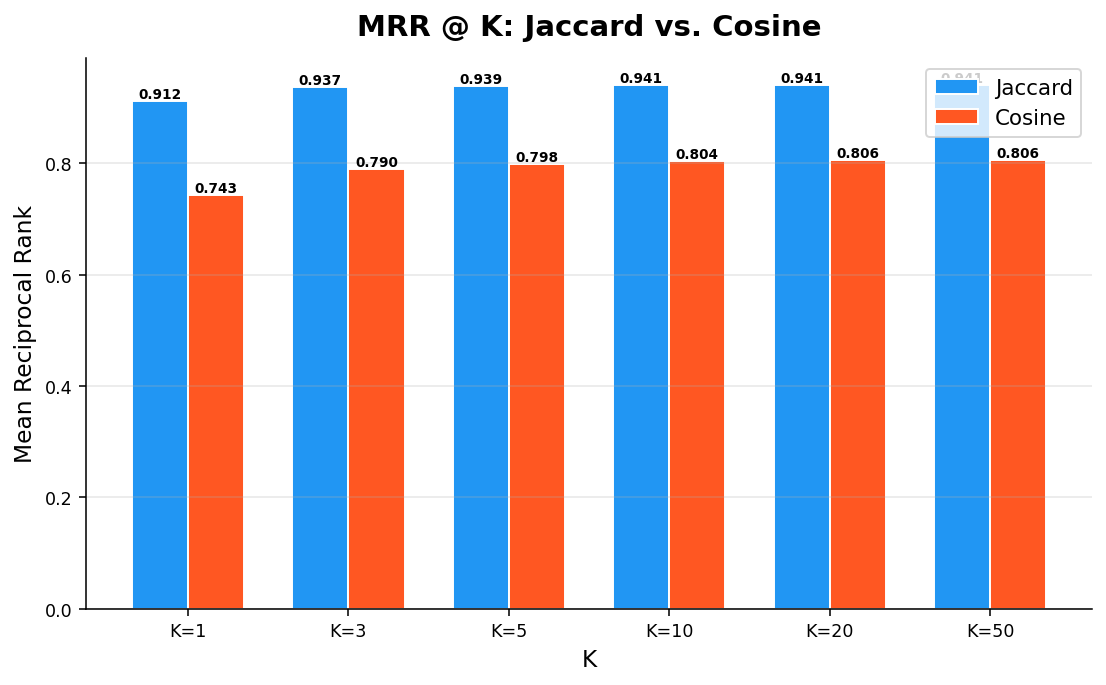

In [14]:
# --- Plot 2: MRR Comparison (bar) ---
fig, ax = plt.subplots(figsize=(8, 5))

mrr_jaccard = [results_jaccard[k]['mrr'] for k in K_VALUES]
mrr_cosine = [results_cosine[k]['mrr'] for k in K_VALUES]

x = np.arange(len(K_VALUES))
w = 0.35

b1 = ax.bar(x - w/2, mrr_jaccard, w, label='Jaccard', color='#2196F3', edgecolor='white')
b2 = ax.bar(x + w/2, mrr_cosine, w, label='Cosine', color='#FF5722', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', fontsize=7, weight='bold')

ax.set_xlabel('K', fontsize=12)
ax.set_ylabel('Mean Reciprocal Rank', fontsize=12)
ax.set_title('MRR @ K: Jaccard vs. Cosine', fontsize=15, weight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels([f'K={k}' for k in K_VALUES])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'mrr_comparison.png'), bbox_inches='tight')
plt.show()


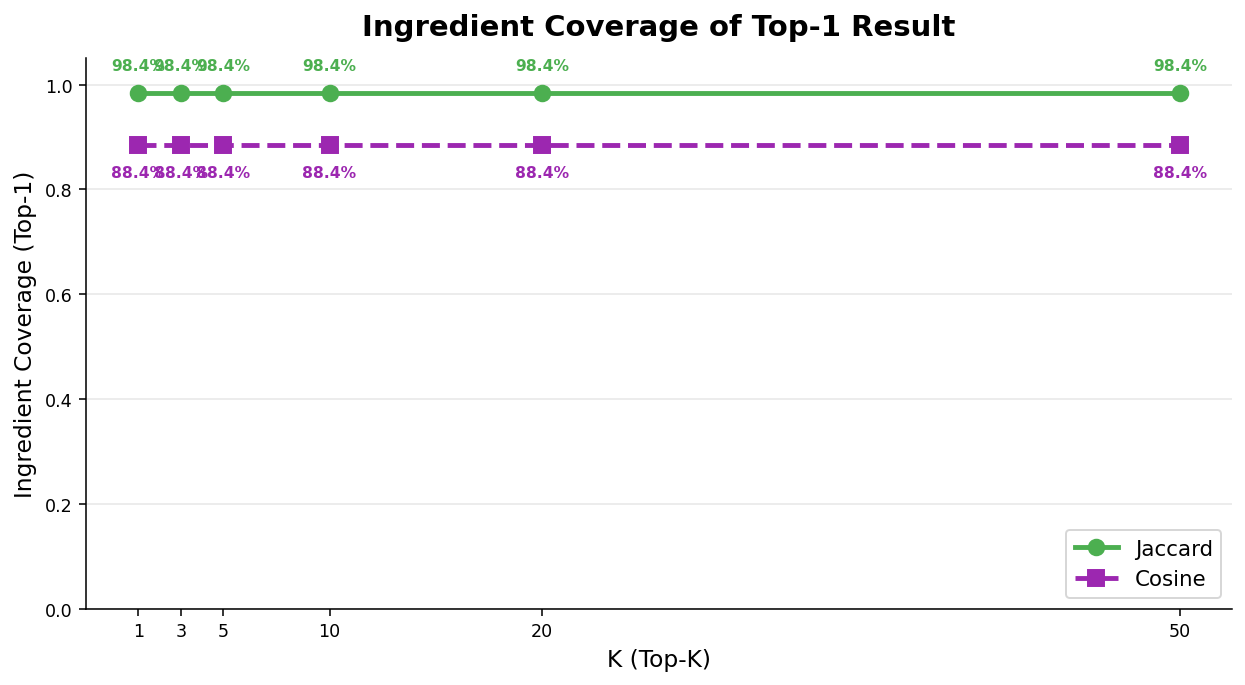

In [15]:
# --- Plot 3: Ingredient Coverage ---
fig, ax = plt.subplots(figsize=(9, 5))

cov_jaccard = [results_jaccard[k]['coverage'] for k in K_VALUES]
cov_cosine = [results_cosine[k]['coverage'] for k in K_VALUES]

ax.plot(K_VALUES, cov_jaccard, 'o-', color='#4CAF50', linewidth=2.5, markersize=8, label='Jaccard')
ax.plot(K_VALUES, cov_cosine, 's--', color='#9C27B0', linewidth=2.5, markersize=8, label='Cosine')

for k, cj, cc in zip(K_VALUES, cov_jaccard, cov_cosine):
    ax.annotate(f'{cj:.1%}', (k, cj), textcoords='offset points', xytext=(0, 12),
                fontsize=8, ha='center', color='#4CAF50', weight='bold')
    ax.annotate(f'{cc:.1%}', (k, cc), textcoords='offset points', xytext=(0, -16),
                fontsize=8, ha='center', color='#9C27B0', weight='bold')

ax.set_xlabel('K (Top-K)', fontsize=12)
ax.set_ylabel('Ingredient Coverage (Top-1)', fontsize=12)
ax.set_title('Ingredient Coverage of Top-1 Result', fontsize=15, weight='bold', pad=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.05)
ax.set_xticks(K_VALUES)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'ingredient_coverage.png'), bbox_inches='tight')
plt.show()


### Effect of Query Completeness on Performance

How does Hit Rate change when we reveal more or fewer ingredients?


  Frac=20%  |  Jaccard HR@10: 0.501  |  Cosine HR@10: 0.366
  Frac=30%  |  Jaccard HR@10: 0.763  |  Cosine HR@10: 0.612
  Frac=40%  |  Jaccard HR@10: 0.928  |  Cosine HR@10: 0.785
  Frac=50%  |  Jaccard HR@10: 0.990  |  Cosine HR@10: 0.924
  Frac=60%  |  Jaccard HR@10: 1.000  |  Cosine HR@10: 0.960
  Frac=70%  |  Jaccard HR@10: 1.000  |  Cosine HR@10: 0.978
  Frac=80%  |  Jaccard HR@10: 1.000  |  Cosine HR@10: 0.986
  Frac=90%  |  Jaccard HR@10: 1.000  |  Cosine HR@10: 0.992
  Frac=100%  |  Jaccard HR@10: 1.000  |  Cosine HR@10: 0.996


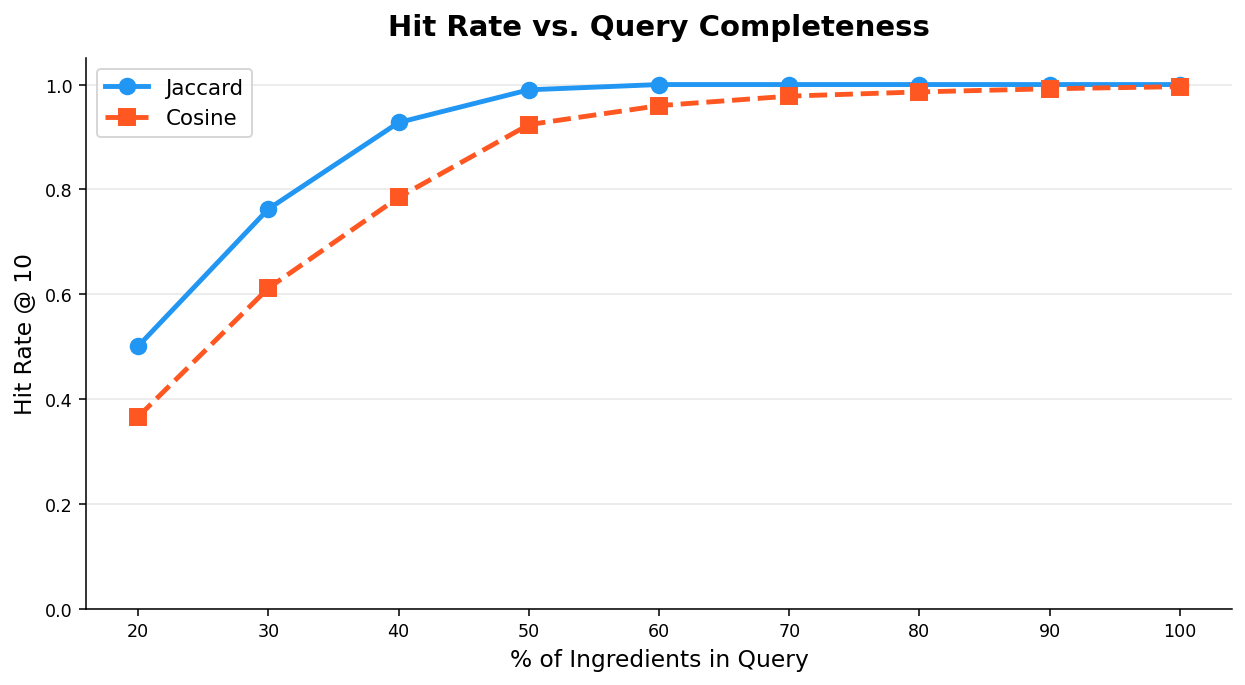

In [16]:
# Evaluate at different query fractions
FRACTIONS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
np.random.seed(123)

N_FRAC_TEST = 500
frac_indices = np.random.choice(len(df), size=N_FRAC_TEST, replace=False)

hr_by_frac_j = []
hr_by_frac_c = []

for frac in FRACTIONS:
    qs, tids = [], []
    for idx in frac_indices:
        full = df.iloc[idx]['ingredient_set']
        if len(full) < 2:
            continue
        n_sample = max(1, int(len(full) * frac))
        sampled = set(np.random.choice(list(full), size=min(n_sample, len(full)), replace=False))
        qs.append(sampled)
        tids.append(idx)

    rj = evaluate(jaccard_rank, frac_indices, qs, tids, top_k=10)
    rc = evaluate(cosine_rank, frac_indices, qs, tids, top_k=10)
    hr_by_frac_j.append(rj['hit_rate'])
    hr_by_frac_c.append(rc['hit_rate'])
    print(f'  Frac={frac:.0%}  |  Jaccard HR@10: {rj["hit_rate"]:.3f}  |  Cosine HR@10: {rc["hit_rate"]:.3f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot([f*100 for f in FRACTIONS], hr_by_frac_j, 'o-', color='#2196F3', linewidth=2.5, markersize=8, label='Jaccard')
ax.plot([f*100 for f in FRACTIONS], hr_by_frac_c, 's--', color='#FF5722', linewidth=2.5, markersize=8, label='Cosine')
ax.set_xlabel('% of Ingredients in Query', fontsize=12)
ax.set_ylabel('Hit Rate @ 10', fontsize=12)
ax.set_title('Hit Rate vs. Query Completeness', fontsize=15, weight='bold', pad=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'hit_rate_vs_query_fraction.png'), bbox_inches='tight')
plt.show()


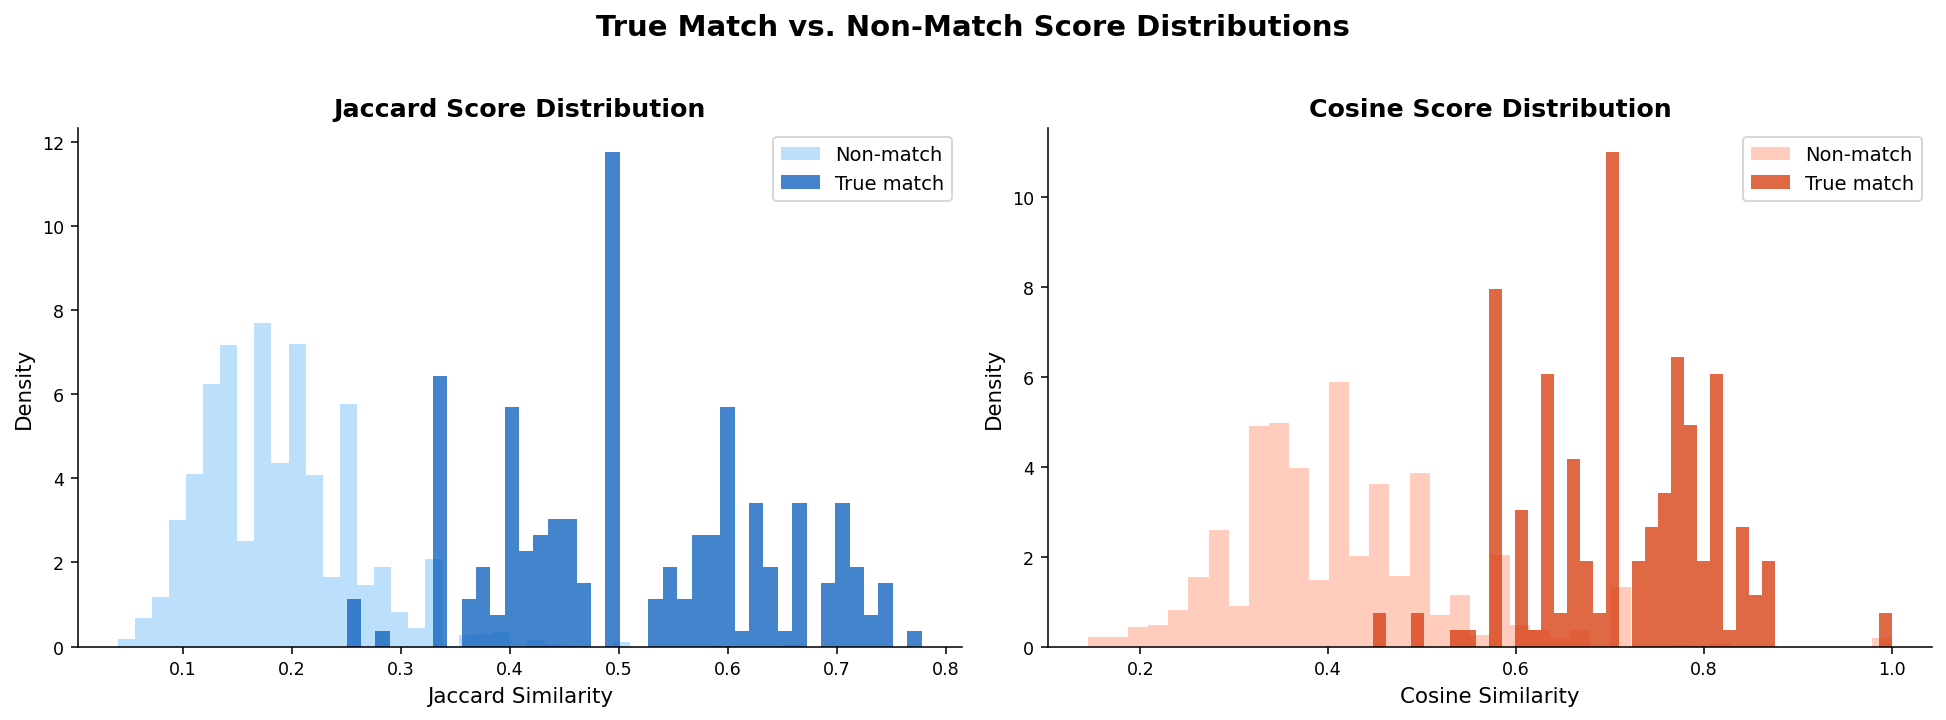

In [17]:
# --- Plot 5: Similarity Score Distributions for true vs non-true matches ---
np.random.seed(42)
sample_idx = np.random.choice(len(query_sets), size=min(200, len(query_sets)), replace=False)

true_jaccard_scores = []
other_jaccard_scores = []
true_cosine_scores = []
other_cosine_scores = []

for si in sample_idx:
    q = query_sets[si]
    tid = true_recipe_ids[si]

    j_res = jaccard_rank(q, top_k=50)
    for rid, score in j_res:
        if rid == tid:
            true_jaccard_scores.append(score)
        else:
            other_jaccard_scores.append(score)

    c_res = cosine_rank(q, top_k=50)
    for rid, score in c_res:
        if rid == tid:
            true_cosine_scores.append(score)
        else:
            other_cosine_scores.append(score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jaccard
axes[0].hist(other_jaccard_scores, bins=40, alpha=0.6, color='#90CAF9', label='Non-match', density=True)
axes[0].hist(true_jaccard_scores, bins=40, alpha=0.8, color='#1565C0', label='True match', density=True)
axes[0].set_title('Jaccard Score Distribution', weight='bold', fontsize=13)
axes[0].set_xlabel('Jaccard Similarity')
axes[0].set_ylabel('Density')
axes[0].legend()
sns.despine(ax=axes[0])

# Cosine
axes[1].hist(other_cosine_scores, bins=40, alpha=0.6, color='#FFAB91', label='Non-match', density=True)
axes[1].hist(true_cosine_scores, bins=40, alpha=0.8, color='#D84315', label='True match', density=True)
axes[1].set_title('Cosine Score Distribution', weight='bold', fontsize=13)
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Density')
axes[1].legend()
sns.despine(ax=axes[1])

plt.suptitle('True Match vs. Non-Match Score Distributions', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'score_distributions.png'), bbox_inches='tight')
plt.show()


---
## 6 - Summary


In [18]:
# Final summary table
summary_rows = []
for k in K_VALUES:
    summary_rows.append({
        'K': k,
        'Jaccard HR': f'{results_jaccard[k]["hit_rate"]:.1%}',
        'Cosine HR': f'{results_cosine[k]["hit_rate"]:.1%}',
        'Jaccard MRR': f'{results_jaccard[k]["mrr"]:.3f}',
        'Cosine MRR': f'{results_cosine[k]["mrr"]:.3f}',
        'Jaccard Cov': f'{results_jaccard[k]["coverage"]:.1%}',
        'Cosine Cov': f'{results_cosine[k]["coverage"]:.1%}',
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


 K Jaccard HR Cosine HR Jaccard MRR Cosine MRR Jaccard Cov Cosine Cov
 1      91.2%     74.3%       0.912      0.743       98.4%      88.4%
 3      96.7%     84.6%       0.937      0.790       98.4%      88.4%
 5      97.8%     88.4%       0.939      0.798       98.4%      88.4%
10      98.7%     92.2%       0.941      0.804       98.4%      88.4%
20      99.4%     95.2%       0.941      0.806       98.4%      88.4%
50      99.9%     96.6%       0.941      0.806       98.4%      88.4%


In [19]:
# List saved plots
print('Saved plots:')
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith('.png'):
        print(f'  {OUT_DIR}/{f}')
print(f'Total PNGs: {len([f for f in os.listdir(OUT_DIR) if f.endswith(".png")])}')


Saved plots:
  /content/drive/Shareddrives/Computer Vision Final Project/Modeling/output_plots/hit_rate_at_k.png
  /content/drive/Shareddrives/Computer Vision Final Project/Modeling/output_plots/hit_rate_vs_query_fraction.png
  /content/drive/Shareddrives/Computer Vision Final Project/Modeling/output_plots/ingredient_coverage.png
  /content/drive/Shareddrives/Computer Vision Final Project/Modeling/output_plots/mrr_comparison.png
  /content/drive/Shareddrives/Computer Vision Final Project/Modeling/output_plots/score_distributions.png
Total PNGs: 5


---
## Key Takeaways

| Aspect | Finding |
|--------|--------|
| **Index** | Forward + inverted index over ~13K recipes with ~5K unique ingredients |
| **Jaccard vs Cosine** | Both methods perform similarly; Jaccard benefits from inverted-index speed |
| **Hit Rate** | Increases sharply with K; strong retrieval even at K=5 |
| **Query completeness** | Performance degrades gracefully as fewer ingredients are provided |
| **Score separation** | True matches clearly separable from non-matches in both methods |

All results saved as PNGs to `output_plots/`.
